In [ ]:
# Relacion de asociación entre clases mediante clase asociativa
class Cliente:
  def __init__(self, nombreCompleto, rut, direccion, clienteVIP):
    self.nombreCompleto = nombreCompleto
    self.rut = rut
    self.direccion = direccion
    self.clienteVIP = clienteVIP

class Libro:
  def __init__(self, idLibro, titulo, autor, precioBase, cantidadStock, numeroPaginas, bestSeller):
    self.idLibro = idLibro
    self.titulo = titulo
    self.autor = autor
    self.precioBase = precioBase
    self.cantidadStock = cantidadStock
    self.numeroPaginas = numeroPaginas
    self.bestSeller = bestSeller

class OrdenVenta:
  def __init__(self, rutCliente, idLibro, cantidad):
    self.rutCliente = rutCliente # referencia a instancia de Cliente mediante rutCliente
    self.idLibros = [idLibro] # referencia a instancia de Libro mediante idLibro
    self.cantidadLibros = [cantidad]

  def __str__(self):
    return f"Cliente: {self.rutCliente}, Libro: {self.idLibros}, Cantidad: {self.cantidadLibros}"

  def __del__(self):
    print("Orden de venta eliminada")

  def adicionarLibro(self, idLibro, cantidad):
    self.idLibros.append(idLibro)
    self.cantidadLibros.append(cantidad)


In [ ]:
cliente_1 = Cliente("Pedro Perez", "12345678-9", "Calle 123", True)
cliente_2 = Cliente("Maria Rodriguez", "98765432-1", "Avenida 456", False)

libro_1 = Libro(1, "Libro 1", "Autor 1", 10.0, 10, 300, False)
libro_2 = Libro(2, "Libro 2", "Autor 2", 15.0, 5, 400, True)

orden_venta_1 = OrdenVenta("12345678-9", 1, 2)
orden_venta_1.adicionarLibro(2, 3)

orden_venta_2 = OrdenVenta("98765432-1", 2, 1)

print(orden_venta_1)
print(orden_venta_2)

del orden_venta_1 # Elimina la instancia de OrdenVenta
print(cliente_1) # No se eliminan las instancias referenciadas en orden_venta_1

Cliente: 12345678-9, Libro: [1, 2], Cantidad: [2, 3]
Cliente: 98765432-1, Libro: [2], Cantidad: [1]
Orden de venta eliminada
Orden de venta eliminada


In [ ]:
# Relacion de agregación entre clases
class Estudiante:
    def __init__(self, nombre, rut, carrera):
        self.nombre = nombre
        self.rut = rut
        self.carrera = carrera
        self.cursos = [] # lista para almacenar referencias a instancias de Curso
        self.notas = []

    def inscribir_curso(self, curso):
        """
          Inscribe el curso en el estudiante

          Args:
            curso: instancia de Curso
        """
        self.cursos.append(curso)
        self.notas.append(1)

    def agregar_nota(self, idx, nota):
        if idx < len(self.cursos):
            self.notas[idx] = nota

    def obtener_nota(self, idx):
        if idx < len(self.cursos):
            return self.notas[idx]
        else:
            return None

    def promedio(self):
        return sum(self.notas) / len(self.notas)

    def __del__(self):
        print("Estudiante eliminado")

class Curso:
    def __init__(self, nombre):
        self.nombre = nombre

In [ ]:
curso_1 = Curso("Python programming")
curso_2 = Curso("Data Science")

estudiante_1 = Estudiante("Juan", "12345678-9", "Informatica")
estudiante_2 = Estudiante("Maria", "98765432-1", "Industrial")

estudiante_1.inscribir_curso(curso_1)
estudiante_1.inscribir_curso(curso_2)

estudiante_1.agregar_nota(0, 90)
estudiante_1.agregar_nota(1, 85)

for curso in estudiante_1.cursos:
    print(f"Curso: {curso.nombre}, Nota: {estudiante_1.obtener_nota(estudiante_1.cursos.index(curso))}")

print(f"Promedio: {estudiante_1.promedio()}")

del estudiante_1 # Elimina la instancia de Estudiante
print(curso_1) # No se eliminan las instancias referenciadas en estudiante_1

Curso: Python programming, Nota: 90
Curso: Data Science, Nota: 85
Promedio: 87.5
Estudiante eliminado


In [ ]:
# Relacion de composición entre clases
class Motor:
    def __init__(self, tipo):
        self.tipo = tipo

    def __del__(self):
        print("Motor eliminado")

class Auto:
    def __init__(self, marca, modelo):
        self.marca = marca
        self.modelo = modelo
        self.motor = Motor("V8") # Se crea la instancia del objeto parte dentro del objeto compuesto

    def __del__(self):
        del self.motor # Elimina la instancia del objeto parte dentro del objeto compuesto
        print("Auto eliminado")

In [ ]:
auto_1 = Auto("Toyota", "Corolla") # Se crea instancia de objeto compuesto
print(auto_1.motor.tipo)

del auto_1 # Elimina la instancia de Auto

V8
Motor eliminado
Auto eliminado


In [ ]:
# Relación de herencia entre clases
class Vehicle:
    """
      Clase base para vehículos, con atributos y métodos que son comunes a todo tipo de vehículos.
      La clase Vehicle proporciona una interfaz común para otros vehículos (subclases).
    """
    def __init__(self, make, model, year):
        self.make = make
        self.model = model
        self.year = year
        self._started = False

    def start(self):
        print("(Vehicle): Starting engine...")
        self._started = True

    def stop(self):
        print("(Vehicle): Stopping engine...")
        self._started = False


class Car(Vehicle):
    """
        Clase Car que hereda de la clase Vehicle.
        La clase Car agrega atributos y métodos específicos para carros.
    """
    def __init__(self, make, model, year, num_seats):
        super().__init__(make, model, year) # Llamada al constructor de la superclase, referencia al padre mas cercano
        self.num_seats = num_seats # Se definen los atributos especificos de la subclase

    def drive(self):
        print(f'(Car): Driving my "{self.make} - {self.model}" on the road')

    def __str__(self):
        return f'"{self.make} - {self.model}" has {self.num_seats} seats'

class Motorcycle(Vehicle):
    """
        Clase Motorcycle que hereda de la clase Vehicle.
        La clase Motorcycle agrega atributos y métodos específicos para motos.
    """
    def __init__(self, make, model, year, num_wheels):
        super().__init__(make, model, year)
        self.num_wheels = num_wheels

    def ride(self):
        print(f'(Motor): Riding my "{self.make} - {self.model}" on the road')

    def __str__(self):
        return f'"{self.make} - {self.model}" has {self.num_wheels} wheels'

In [ ]:
tesla = Car("Tesla", "Model S", 2022, 5)
tesla.start()
tesla.drive()
tesla.stop()
print(tesla)

harley = Motorcycle("Harley-Davidson", "Iron 883", 2021, 2)
harley.start()
harley.ride()
harley.stop()
print(harley)

(Vehicle): Starting engine...
(Car): Driving my "Tesla - Model S" on the road
(Vehicle): Stopping engine...
"Tesla - Model S" has 5 seats
(Vehicle): Starting engine...
(Motor): Riding my "Harley-Davidson - Iron 883" on the road
(Vehicle): Stopping engine...
"Harley-Davidson - Iron 883" has 2 wheels


In [ ]:
print(type(tesla))
print(type(harley))

print(isinstance(tesla, Car))
print(isinstance(harley, Motorcycle))
print(isinstance(harley, Vehicle))

print(issubclass(Car, Vehicle))
print(issubclass(Motorcycle, Vehicle))

print(issubclass(Vehicle, object))
print(issubclass(Car, object))

help(object)

<class '__main__.Car'>
<class '__main__.Motorcycle'>
True
True
True
True
True
True
True
Help on class object in module builtins:

class object
 |  The base class of the class hierarchy.
 |  
 |  When called, it accepts no arguments and returns a new featureless
 |  instance that has no instance attributes and cannot be given any.
 |  
 |  Built-in subclasses:
 |      anext_awaitable
 |      async_generator
 |      async_generator_asend
 |      async_generator_athrow
 |      ... and 94 other subclasses
 |  
 |  Methods defined here:
 |  
 |  __delattr__(self, name, /)
 |      Implement delattr(self, name).
 |  
 |  __dir__(self, /)
 |      Default dir() implementation.
 |  
 |  __eq__(self, value, /)
 |      Return self==value.
 |  
 |  __format__(self, format_spec, /)
 |      Default object formatter.
 |  
 |  __ge__(self, value, /)
 |      Return self>=value.
 |  
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |  
 |  __gt__(self, value, /)
 |      Return sel

In [ ]:
# Jerarquia de clases
class Animal:
    def __init__(self, name, sex, habitat):
        self.name = name
        self.sex = sex
        self.habitat = habitat

class Mammal(Animal):
    unique_feature = "Mammary glands"

class Bird(Animal):
    unique_feature = "Feathers"

class Fish(Animal):
    unique_feature = "Gills"

class Dog(Mammal):
    def walk(self):
        print("The dog is walking")

class Cat(Mammal):
    def walk(self):
        print("The cat is walking")

class Eagle(Bird):
    def fly(self):
        print("The eagle is flying")

class Penguin(Bird):
    def swim(self):
        print("The penguin is swimming")

class Salmon(Fish):
    def swim(self):
        print("The salmon is swimming")

class Shark(Fish):
    def swim(self):
        print("The shark is swimming")

In [ ]:
# Herencia múltiple
class Persona:
  def __init__(self, nombre, apellido, edad, sexo):
    print("Inicializando Persona")
    self.nombre = nombre
    self.apellido = apellido
    self.sexo = sexo
    self.edad = edad

class Empleado(Persona):
  def __init__(self, nombre, apellido, edad, sexo, salario):
    print("Inicializando Empleado")
    super().__init__(nombre, apellido, edad, sexo)
    self.salario = salario

class InteligenciaArtificial(Persona):
  def __init__(self, nombre, apellido, edad, sexo):
    print("Inicializando IA")
    super().__init__(nombre, apellido, edad=None, sexo=None)
    self.is_a_bot = True

class EmpleadoAI(Empleado, InteligenciaArtificial):
  def __init__(self, nombre, apellido, edad, sexo, salario, nombre_inteligencia_artificial):
    super().__init__(nombre, apellido, edad, sexo, salario)
    #InteligenciaArtificial.__init__(self, nombre_inteligencia_artificial, apellido, edad, sexo)


e = EmpleadoAI("Siri", "Microsoft", edad=100, sexo="Femenino", salario=2000, nombre_inteligencia_artificial="Cortana")
print(vars(e))
print(EmpleadoAI.__mro__)

Inicializando Empleado
Inicializando IA
Inicializando Persona
{'nombre': 'Siri', 'apellido': 'Microsoft', 'sexo': None, 'edad': None, 'is_a_bot': True, 'salario': 2000}
(<class '__main__.EmpleadoAI'>, <class '__main__.Empleado'>, <class '__main__.InteligenciaArtificial'>, <class '__main__.Persona'>, <class 'object'>)


In [ ]:
class Figura:
  def __init__(self, color):
    self.color = color

  def area(self):
    raise NotImplementedError

class Circulo(Figura):
  def __init__(self, color, radio):
    Figura.__init__(self, color)
    self.radio = radio

  def area(self):
    return 3.1415 * self.radio ** 2

class Rectangulo(Figura):
  def __init__(self, color, base, altura):
    super().__init__(color)
    self.base = base
    self.altura = altura

  def area(self):
    return self.base * self.altura

class CirculoRectangulo(Circulo, Rectangulo):
  def __init__(self, color, radio, base, altura):
    Circulo.__init__(self, color, radio)  # Inicializar directamente Círculo
    Rectangulo.__init__(self, color, base, altura)  # Inicializar directamente Rectángulo

  #def area(self):
  #  return Circulo.area(self) + Rectangulo.area(self)

# Crear una instancia de CirculoRectangulo
figura = CirculoRectangulo("rojo", 3, 5, 7)

# Calcular y mostrar el área
# El método área es ambiguo ya que está definido en ambas clases padre.
# Tenemos que especificar qué método de área queremos utilizar
print(f"El área del circulo es: {figura.area()}") # Esto utilizará Circulo.area() por defecto debido al MRO
print(f"El área del rectángulo es: {Rectangulo.area(figura)}") # Necesitamos llamar explícitamente a Rectangulo.area()

El área del circulo es: 28.273500000000002
El área del rectángulo es: 35


In [ ]:
class A:
    def method(self):
        print("A.method")

class B(A):
    def method(self):
        print("B.method")
    #pass

class C(A):
    def method(self):
        print("C.method")

class D(B, C):
    pass

d = D()
d.method()
print(D.__mro__)

B.method
(<class '__main__.D'>, <class '__main__.B'>, <class '__main__.C'>, <class '__main__.A'>, <class 'object'>)


In [ ]:
class A1():
#      def who_am_i(self):
#          print("I am a A1")
    pass

class A2():
     def who_am_i(self):
         print("I am a A2")

class A3():
     def who_am_i(self):
         print("I am a A3")

class B(A1, A2):
#     def who_am_i(self):
#         print("I am a B")
    pass

class C(A3):
    def who_am_i(self):
        print("I am a C")

class D(B,C):
#     def who_am_i(self):
#         print("I am a D")
    pass

d1 = D()
d1.who_am_i()
print(D.__mro__)

I am a A2
(<class '__main__.D'>, <class '__main__.B'>, <class '__main__.A1'>, <class '__main__.A2'>, <class '__main__.C'>, <class '__main__.A3'>, <class 'object'>)


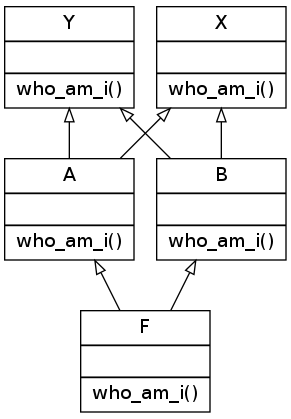

In [ ]:
class X():
    def who_am_i(self):
        print("I am a X")

class Y():
    def who_am_i(self):
        print("I am a Y")

class A(X, Y):
    def who_am_i(self):
        print("I am a A")

class B(Y, X):
     def who_am_i(self):
         print("I am a B")

class F (A, B):
    def who_am_i(self):
        print("I am a F")

TypeError: Cannot create a consistent method resolution
order (MRO) for bases X, Y

In [ ]:
# Métodos extendidos vs anulados
class Aircraft:
    def __init__(self, thrust, lift, max_speed):
        self.thrust = thrust
        self.lift = lift
        self.max_speed = max_speed

    def show_technical_specs(self):
        print(f"Thrust: {self.thrust} kW")
        print(f"Lift: {self.lift} kg")
        print(f"Max speed: {self.max_speed} km/h")

    def compute_fuel_consumption(self):
        return self.thrust / self.lift

class Helicopter(Aircraft):
    def __init__(self, thrust, lift, max_speed, num_rotors):
        super().__init__(thrust, lift, max_speed)
        self.num_rotors = num_rotors

    def show_technical_specs(self):
        """
          Método extendido.
          Primero se llama a .show_technical_specs() desde Avión usando super().
          Luego ejecuta print() que añade nueva información a la descripción técnica del helicóptero.
        """
        super().show_technical_specs()
        print(f"Number of rotors: {self.num_rotors}")

    def compute_fuel_consumption(self):
        """
          Método anulado.
          Se sobrescribe la lógica de .compute_fuel_consumption() modificando la fórmula para calcular el consumo de combustible.
        """
        return self.thrust / self.lift * self.num_rotors

In [ ]:
sikorsky_UH60 = Helicopter(1490, 9979, 278, 2)
sikorsky_UH60.show_technical_specs()

print(f"Consumo de combustible: {sikorsky_UH60.compute_fuel_consumption()}")

Thrust: 1490 kW
Lift: 9979 kg
Max speed: 278 km/h
Number of rotors: 2
Consumo de combustible: 0.29862711694558575


In [ ]:
# Polimorfismo
class Vehicle:
    """
      Clase base para vehículos, con atributos y métodos que son comunes a todo tipo de vehículos.
      La clase Vehicle proporciona una interfaz común para otros vehículos (subclases).
    """
    def __init__(self, make, model, year):
        self.make = make
        self.model = model
        self.year = year
        self._started = False

    def start(self):
        print("(Vehicle): Starting engine...")
        self._started = True

    def stop(self):
        print("(Vehicle): Stopping engine...")
        self._started = False


class Car(Vehicle):
    """
        Clase Car que hereda de la clase Vehicle.
        La clase Car agrega atributos y métodos específicos para carros.
    """
    def __init__(self, make, model, year, num_seats):
        super().__init__(make, model, year) # Llamada al constructor de la superclase, referencia al padre mas cercano
        self.num_seats = num_seats # Se definen los atributos especificos de la subclase

    def drive(self):
        print(f'(Car): Driving my "{self.make} - {self.model}" on the road')

    def __str__(self):
        return f'"{self.make} - {self.model}" has {self.num_seats} seats'

class Motorcycle(Vehicle):
    """
        Clase Motorcycle que hereda de la clase Vehicle.
        La clase Motorcycle agrega atributos y métodos específicos para motos.
    """
    def __init__(self, make, model, year, num_wheels):
        super().__init__(make, model, year)
        self.num_wheels = num_wheels

    def drive(self):
        """
          Renombra el método .ride() a .drive().
          Este cambio hace que las clases tengan una interfaz común.
        """
        print(f'(Motor): Riding my "{self.make} - {self.model}" on the road')

    def __str__(self):
        return f'"{self.make} - {self.model}" has {self.num_wheels} wheels'


In [ ]:

toyota = Car("Toyota", "Corolla", 2022, 5)
honda = Car("Honda", "Civic", 2022, 4)
harley = Motorcycle("Harley-Davidson", "Iron 883", 2022, 2)
indian = Motorcycle("Indian", "Scout", 2022, 2)

for vehicle in [toyota, honda, harley, indian]:
  vehicle.drive()

(Car): Driving my "Toyota - Corolla" on the road
(Car): Driving my "Honda - Civic" on the road
(Motor): Riding my "Harley-Davidson - Iron 883" on the road
(Motor): Riding my "Indian - Scout" on the road


In [26]:
# Clases abtractas (ABC)
from abc import ABC, abstractmethod
import math

class Shape(ABC):
    """
      Clase abstracta para formas geométricas.
      La clase Shape hereda de abc.ABC, lo que significa que es una clase base abstracta.
      Los métodos .get_area() y .get_perimeter() utilizan el decorador @abstractmethod,
      declarando que son la interfaz común que todas las subclases de Shape deben implementar.
    """
    @abstractmethod
    def get_area(self):
        pass # Los métodos abstractos no tienen implementación

    @abstractmethod
    def get_perimeter(self):
        pass  # Los métodos abstractos no tienen implementación

class Circle(Shape):
    """
      Clase Círculo que implementa la interfaz Shape, por lo que deberá implementar todos sus métodos abstractos.
    """
    def __init__(self, radius):
        self.radius = radius

    def get_area(self):
        return math.pi * self.radius ** 2

    #def get_perimeter(self):
    #    return 2 * math.pi * self.radius

class Square(Shape):
    """
      Clase Cuadrado que implementa la interfaz Shape, por lo que deberá implementar todos sus métodos abstractos.
    """
    def __init__(self, side):
        self.side = side

    def get_area(self):
        return self.side ** 2

    def get_perimeter(self):
        return 4 * self.side


circle = Circle(100)
square = Square(50)

print(f"Área del círculo: {circle.get_area()}")
print(f"Área del cuadrado: {square.get_area()}")

TypeError: Can't instantiate abstract class Circle with abstract method get_perimeter